In [1]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

import os
from dotenv import load_dotenv
_ = load_dotenv()

model = ChatOllama(
    model="gpt-oss:20b",
    num_ctx=16*1024,
    keep_alive=-1,
    temperature=0,
    client_kwargs={
        "headers": {
            "authorization": os.getenv("OLLAMA_API_KEY")
        }
    }
)

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver()
)

config = {
    "configurable": {
        "thread_id": "conversation-1"
    }
}

agent.invoke({"messages": [{"role":"user", "content":"hi"}]}, config=config)

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='a598c6ae-9c36-4da2-af71-55f33bb10acd'),
  AIMessage(content='Hello! 👋 How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-08-02T05:17:52.032852165Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1167666002, 'load_duration': 556989204, 'prompt_eval_count': 68, 'prompt_eval_duration': 45145000, 'eval_count': 42, 'eval_duration': 553895000, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019fc0e8-34a1-7773-b83f-5c7f353ce929-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 42, 'total_tokens': 110})]}

In [5]:
thread_id = agent.config["metadata"]["thread_id"]

state = agent.get_state(config={"configurable": {"thread_id": thread_id}})

state

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='3718c6e4-1126-451b-b2fe-5a74fc5d8d9e'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-08-02T05:16:38.19369828Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1129478370, 'load_duration': 552352099, 'prompt_eval_count': 68, 'prompt_eval_duration': 58847000, 'eval_count': 35, 'eval_duration': 458090000, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019fc0e7-160a-7530-bf18-077e1bc6ae6a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 35, 'total_tokens': 103})]}, next=(), config={'configurable': {'thread_id': 'conversation-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18e315-720c-6a67-8001-77b58ccb15e6'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}, 'ls_integration': 'langchain_create_

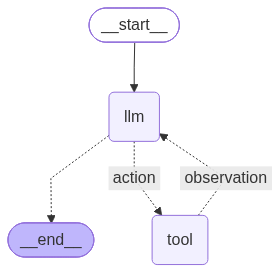

In [6]:
from agentic_ai.agents.react_agent import ReActAgent

agent = ReActAgent(llm=model, tools=[])

agent._build_graph().compile()